<a href="https://colab.research.google.com/github/sathishgowdaRS/Deep-learning-/blob/main/Deep_Learning_MNIST_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


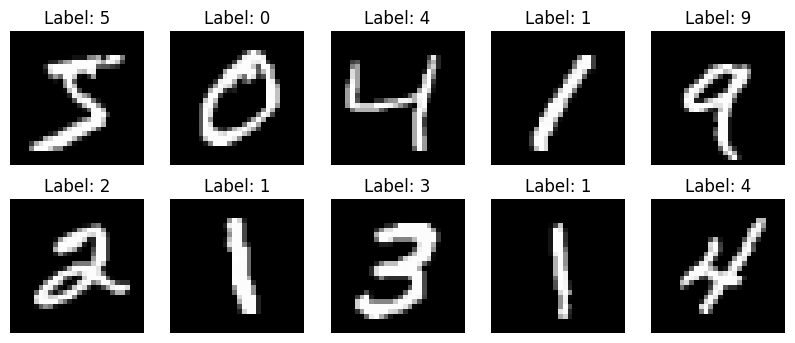

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")
plt.show()


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0



In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9206 - loss: 0.2796 - val_accuracy: 0.9657 - val_loss: 0.1192
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9629 - loss: 0.1244 - val_accuracy: 0.9713 - val_loss: 0.1008
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9741 - loss: 0.0858 - val_accuracy: 0.9747 - val_loss: 0.0850
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9806 - loss: 0.0651 - val_accuracy: 0.9763 - val_loss: 0.0831
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9762 - val_loss: 0.0814


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9738 - loss: 0.0869
Test Accuracy: 0.973800003528595


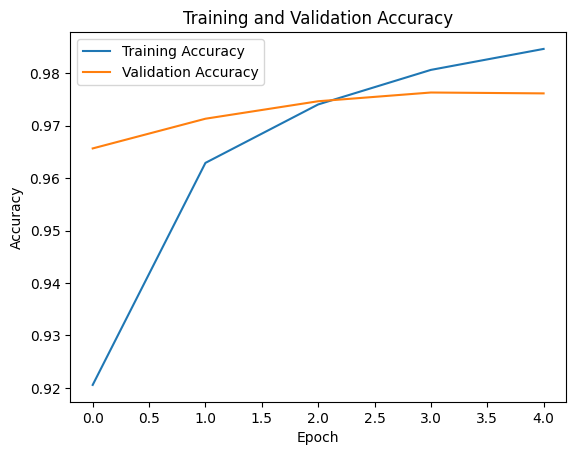

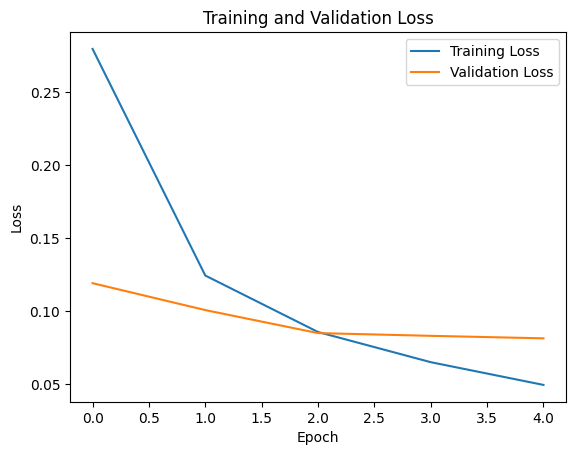

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


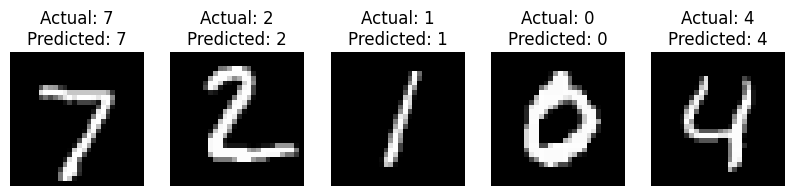

Actual Labels:    [7 2 1 0 4]
Predicted Labels: [7 2 1 0 4]


In [ ]:
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis("off")

plt.show()

print("Actual Labels:   ", y_test[:5])
print("Predicted Labels:", predicted_labels)

In [ ]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model2.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test, verbose=0)

print("\nEXPERIMENT COMPARISON")
print("Original Model (128 neurons):", test_accuracy)
print("Modified Model (64 neurons):", test_accuracy2)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9117 - loss: 0.3159 - val_accuracy: 0.9593 - val_loss: 0.1475
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9556 - loss: 0.1498 - val_accuracy: 0.9688 - val_loss: 0.1102
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9675 - loss: 0.1088 - val_accuracy: 0.9728 - val_loss: 0.0996
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9729 - loss: 0.0875 - val_accuracy: 0.9732 - val_loss: 0.0993
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9786 - loss: 0.0714 - val_accuracy: 0.9702 - val_loss: 0.0978

EXPERIMENT COMPARISON
Original Model (128 neurons): 0.973800003528595
Modified Model (64 neurons): 0.9681000113487244
